# Phase 2: Unsupervise Discovery (NER)

## set up

In [1]:
# Import necessary libraries
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import spacy
from spacy import displacy
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import TruncatedSVD, NMF
from sklearn.decomposition import LatentDirichletAllocation

# Setup Thai font for matplotlib
!wget -q -O thsarabunnew-webfont.ttf https://github.com/PyThaiNLP/prachathai-67k/raw/master/thsarabunnew-webfont.ttf

fm.fontManager.addfont("thsarabunnew-webfont.ttf")
plt.rc('font', family='TH Sarabun New')

print("Setup complete. Libraries and models are ready.")

Setup complete. Libraries and models are ready.


In [2]:
%pip install pythainlp python-crfsuite

Note: you may need to restart the kernel to use updated packages.


## load dataset

The assignment said "ข้อมูลที่ Scrape มาใหม่"

In [3]:
from datasets import load_dataset

# thaipbs-news dataset (scraped)
tpbs_ds = load_dataset("szzs1693/nlp-thaipbs-news")

In [4]:
tpbs_df = tpbs_ds['train'].to_pandas()
tpbs_df.head()

,url,title,categoryName,abstract,publishedTime,tags,content_html,content_text
0,https://www.thaipbs.or.th/news/content/355884,"""อาร์เจนตินา"" ประตูสู่ ลาตินอเมริกา โอกาส ""ยา...",เศรษฐกิจ,,2025-09-01 03:38:00,"[อาร์เจนตินา, ส่งออกสินค้าไทย, ตลาดส่งออกไทย, ...","<p><strong><em>""บัวโนสไอเรส"" เมืองหลวงของอาร์เ...","""บัวโนสไอเรส"" เมืองหลวงของอาร์เจนตินา ตั้งอยู่..."
1,https://www.thaipbs.or.th/news/content/356014,“เนื้อโคขุน” สุรินทร์ ของดีเมืองไทย รสชาตินุ่ม...,เศรษฐกิจ,,2025-09-02 04:43:00,"[เนื้อสุรินทร์, เนื้อโคขุน, เนื้อโค, โคขุน, จั...",<p><em><strong>“สีแดงอมชมพู ลายไขมันแทรกสวย” เ...,“สีแดงอมชมพู ลายไขมันแทรกสวย” เมื่อปรุงสุกจะได...
2,https://www.thaipbs.or.th/news/content/356017,เปิดนำเข้าพ่อแม่พันธุ์ไก่ “รมว.เกษตรฯ”ถก บอร์ด...,เศรษฐกิจ,“รมว.เกษตรฯ” ถกบอร์ดไข่ไก่ ยันผู้ประกอบการขอนำ...,2025-09-01 08:40:00,"[ไข่ไก่, พ่อพันธุ์แม่พันธุ์ไก่, นำเข้าพ่อแม่พั...",<p>วันนี้ ( 1 ก.ย.2568) นายอรรถกร ศิริลัทธยากร...,วันนี้ ( 1 ก.ย.2568) นายอรรถกร ศิริลัทธยากร รม...
3,https://www.thaipbs.or.th/news/content/356047,พณ.ดันอาเซียน–อินเดีย ทบทวนข้อตกลงการค้าเปิดทา...,เศรษฐกิจ,พาณิชย์ ถกรมว.อาเซียน-อินเดีย ดันทบทวนความตกลง...,2025-09-02 05:40:40,"[ความตกลงการค้าสินค้าอาเซียน–อินเดีย, อาเซียนอ...",<p>วันนี้ ( 2 ก.ย.2568) นายฉันทวิชญ์ ตัณฑสิทธิ...,วันนี้ ( 2 ก.ย.2568) นายฉันทวิชญ์ ตัณฑสิทธิ์ ร...
4,https://www.thaipbs.or.th/news/content/356067,ไทยส่งออกสัตว์น้ำได้ฉลุย หลังสหรัฐฯประกาศผ่านเ...,เศรษฐกิจ,ข่าวดี สหรัฐฯ ประกาศ ไทยผ่านเกณฑ์มาตรฐาน MMPA ...,2025-09-02 08:59:13,"[กรมประมง, ส่งออกสัตว์น้ำ, สินค้าสัตว์น้ำไทย, ...",<p>วันนี้ ( 2 ก.ย.2568) นายบัญชา สุขแก้ว อธิบด...,วันนี้ ( 2 ก.ย.2568) นายบัญชา สุขแก้ว อธิบดีกร...


## NER

In [5]:
# # Custom text modifications
tpbs_df['text'] = tpbs_df['content_text']

tpbs_df['text'] = tpbs_df['text'].str.replace("ลาติมอเมริกา", "ลาตินอเมริกา")
#tpbs_df['text'] = tpbs_df['text'].str.replace(" ม. ", " เมตร ")
#tpbs_df['text'] = tpbs_df['text'].str.replace(" ม.", "มหาวิทยาลัย ")
#tpbs_df['text'] = tpbs_df['text'].str.replace("ครม.", "คณะรัฐมนตรี")
#tpbs_df['text'] = tpbs_df['text'].str.replace("กทม.", "กรุงเทพมหานคร")

In [6]:
from spacy import displacy

# Convert pythainlp NER output to displacy manual format for entity visualization
def to_spacy(ner_result):
    text_tokens = [token for token, _ in ner_result]
    full_text = "".join(text_tokens)

    entities = []
    current_entity = None
    char_index = 0

    for token, tag in ner_result:
        if tag.startswith("B-"):
            if current_entity: # If there was a previous entity that just ended
                current_entity["end"] = char_index
                entities.append(current_entity)

            entity_type = tag[2:] # Remove "B-"
            current_entity = {
                "start": char_index,
                "label": entity_type
            }
        elif tag.startswith("I-"):
            # Continue the current entity
            pass
        else: # tag == 'O'
            if current_entity: # If an entity just ended
                current_entity["end"] = char_index
                entities.append(current_entity)
                current_entity = None

        char_index += len(token)

    # Add the last entity if it hasn't been added
    if current_entity:
        current_entity["end"] = char_index
        entities.append(current_entity)

    return {
        "text": full_text,
        "ents": entities,
        "title": None
    }

In [7]:
from pythainlp.tag import NER

ner = NER("thainer")

In [8]:
from pythainlp.tokenize import sent_tokenize

def tokenize(text: str) -> str:
    sentences = sent_tokenize(text, engine="crfcut")
    return sentences

In [9]:
sample_sentences = tokenize(tpbs_df['text'][0])
sample_sentences[0:10]

['"บัวโนสไอเรส" เมืองหลวงของอาร์เจนตินา ตั้งอยู่ทางตอนใต้ของทวีปอเมริกาใต้ ',
 'ติดชิลี โบลิเวีย ปารากวัย บราซิล อุรุกวัย และมหาสมุทรแอตแลนติก ที่นี่ถือเป็น ตลาดยุทธศาสตร์และประตูสำคัญสู่ลาตินอเมริกา ด้วยเป็นตลาดขนาดใหญ่ของประเทศ ',
 'มีความเชื่อมโยงการค้าผ่าน MERCOSUR และยังมีศักยภาพด้านอาหาร พลังงาน และเหมืองแร่\nนับเป็นตลาดใหม่ของไทยและยังเป็นจุดเริ่มต้นการเจาะตลาดลาตินอเมริกา ทั้งสินค้าอุตสาหกรรม เทคโนโลยี และเกษตร–อาหาร ',
 'แม้ภาพรวมเศรษฐกิจอาร์เจนตินาจะค่อยข้างผันผวน ',
 'โดยเฉพาะปัญหาเงินเฟ้อที่สูงเกือบ 100% แต่รัฐบาลชุดปัจจุบันมีนโยบายเปิดการค้ากับนานาประเทศ ',
 'แก้ไขวิกฤตเศรษฐกิจ ',
 'ไม่ว่าจะเป็น ลดค่าเงินเปโซ เพื่อสร้างความได้เปรียบทางการค้าและกระตุ้นการส่งออก เปิดเสรีการค้า ',
 'ยกเลิกการควบคุมเงินทุนและปรับลดภาษีศุลกากรเพื่อดึงดูดการลงทุนจากต่างประเทศ\n\nกระทรวงพาณิชย์ โดยกรมส่งเสริมการค้าระหว่างประเทศ มองว่า การเปิดการค้ากับตลาดอาร์เจนติน่า หรือภูมิภาคลาตินอเมริกาจะเป็นโอกาสของผู้ประกอบการไทย ',
 'โดยเฉพาะอุตสาหกรรมหนัก อย่างยานยนต์และชิ้นส่วนประกอบ เพราะอาร์เจนตินาถือว

In [10]:
# Visualize NER results for all sentences in the first sample entry
print("Visualizing NER results for all sentences in sample record:")
for i, sentence in enumerate(sample_sentences[0:10]):
    print(f"Sentence {i+1}:")
    ner_sentence_result = ner.tag(sentence)
    displacy.render(to_spacy(ner_sentence_result), style="ent", manual=True, jupyter=True)

Visualizing NER results for all sentences in sample record:
Sentence 1:


Sentence 2:


Sentence 3:


Sentence 4:


Sentence 5:


Sentence 6:


Sentence 7:


Sentence 8:


Sentence 9:


Sentence 10:


In [11]:
from tqdm import tqdm
# This cell is slow (~5–10 min depending on hardware). Run once and proceed.
tqdm.pandas(desc="Tokenizing Sentences")
tpbs_df["sentences"] = tpbs_df["text"].progress_apply(tokenize)

Tokenizing Sentences: 100%|█████████████████| 1200/1200 [00:19<00:00, 60.07it/s]


In [12]:
# Number of sentences across all articles
tpbs_df["sentences"].str.len().describe()

count    1200.000000
mean       37.227500
std        24.800302
min         6.000000
25%        21.000000
50%        31.000000
75%        46.000000
max       213.000000
Name: sentences, dtype: float64

## Perform NER on Sentences

In [13]:
def process_sentences_for_ner(sentence_list):
    """
    Applies NER to each sentence in a list of sentences.
    """
    ner_results = []
    for sentence in sentence_list:
        ner_results.append(ner.tag(sentence))
    return ner_results

# Apply the function to the 'sentences' column and store the results in 'ner_sentences'
tqdm.pandas(desc='NER')
tpbs_df["ner_sentences"] = tpbs_df["sentences"].progress_apply(process_sentences_for_ner)

NER: 100%|██████████████████████████████████| 1200/1200 [00:27<00:00, 42.87it/s]


## Entity Extraction & Aggregation

In [14]:
def extract_entities(ner_sentences):
    """Extract all named entities from a list of NER-tagged sentences."""
    entities = []
    for sentence in ner_sentences:
        current_tokens = []
        current_type = None
        for token, tag in sentence:
            if tag.startswith("B-"):
                if current_tokens:
                    entities.append(("".join(current_tokens), current_type))
                current_tokens = [token]
                current_type = tag[2:]
            elif tag.startswith("I-") and current_tokens:
                current_tokens.append(token)
            else:
                if current_tokens:
                    entities.append(("".join(current_tokens), current_type))
                    current_tokens = []
                    current_type = None
        if current_tokens:
            entities.append(("".join(current_tokens), current_type))
    return entities

# Build a flat DataFrame of all entities with their source article's category
records = []
for _, row in tpbs_df.iterrows():
    for entity_text, entity_type in extract_entities(row["ner_sentences"]):
        records.append({
            "entity": entity_text,
            "entity_type": entity_type,
            "category": row["categoryName"],
        })

entities_df = pd.DataFrame(records)
print(f"Total entity mentions: {len(entities_df):,}")
print(f"Unique entities: {entities_df['entity'].nunique():,}")
print(f"\nEntity type counts:")
print(entities_df["entity_type"].value_counts())

Total entity mentions: 39,174
Unique entities: 13,222

Entity type counts:
entity_type
LOCATION        11308
ORGANIZATION     8607
PERSON           6844
DATE             4255
MONEY            2639
TIME             2446
PERCENT          2224
LAW               536
LEN               153
URL               128
ZIP                31
EMAIL               2
PHONE               1
Name: count, dtype: int64


## Entity Type Distribution

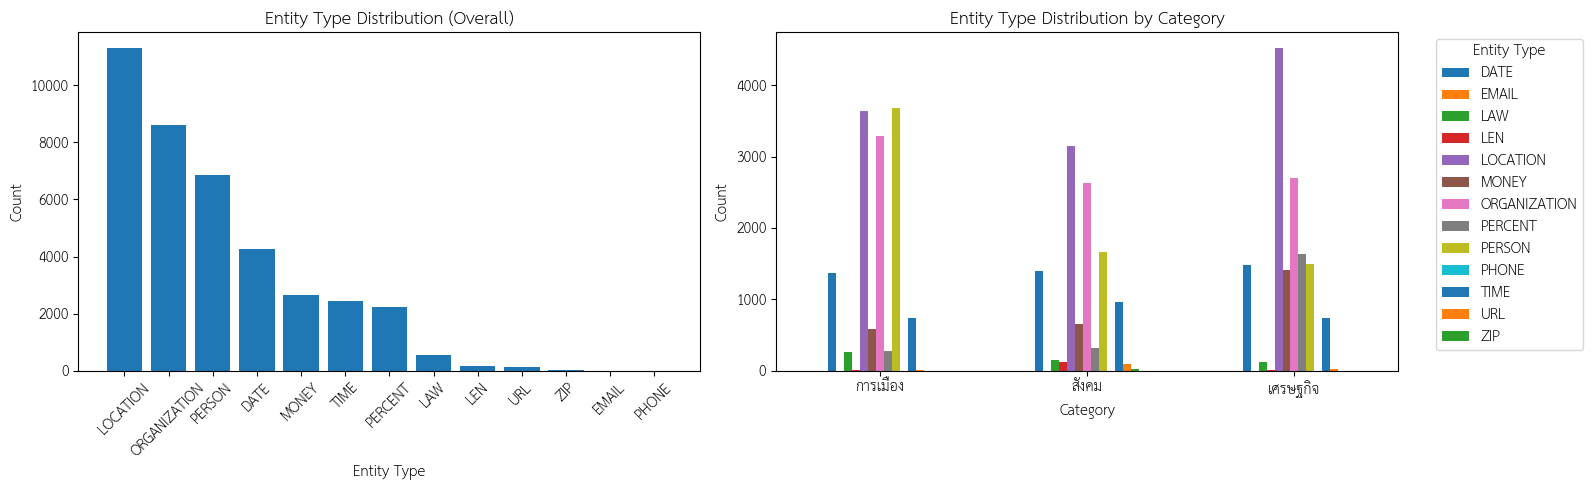

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Overall entity type distribution
type_counts = entities_df["entity_type"].value_counts()
axes[0].bar(type_counts.index, type_counts.values)
axes[0].set_title("Entity Type Distribution (Overall)")
axes[0].set_xlabel("Entity Type")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

# Entity type distribution per category
cat_type = entities_df.groupby(["category", "entity_type"]).size().unstack(fill_value=0)
cat_type.plot(kind="bar", ax=axes[1])
axes[1].set_title("Entity Type Distribution by Category")
axes[1].set_xlabel("Category")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(title="Entity Type", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

## Top Entities per Type

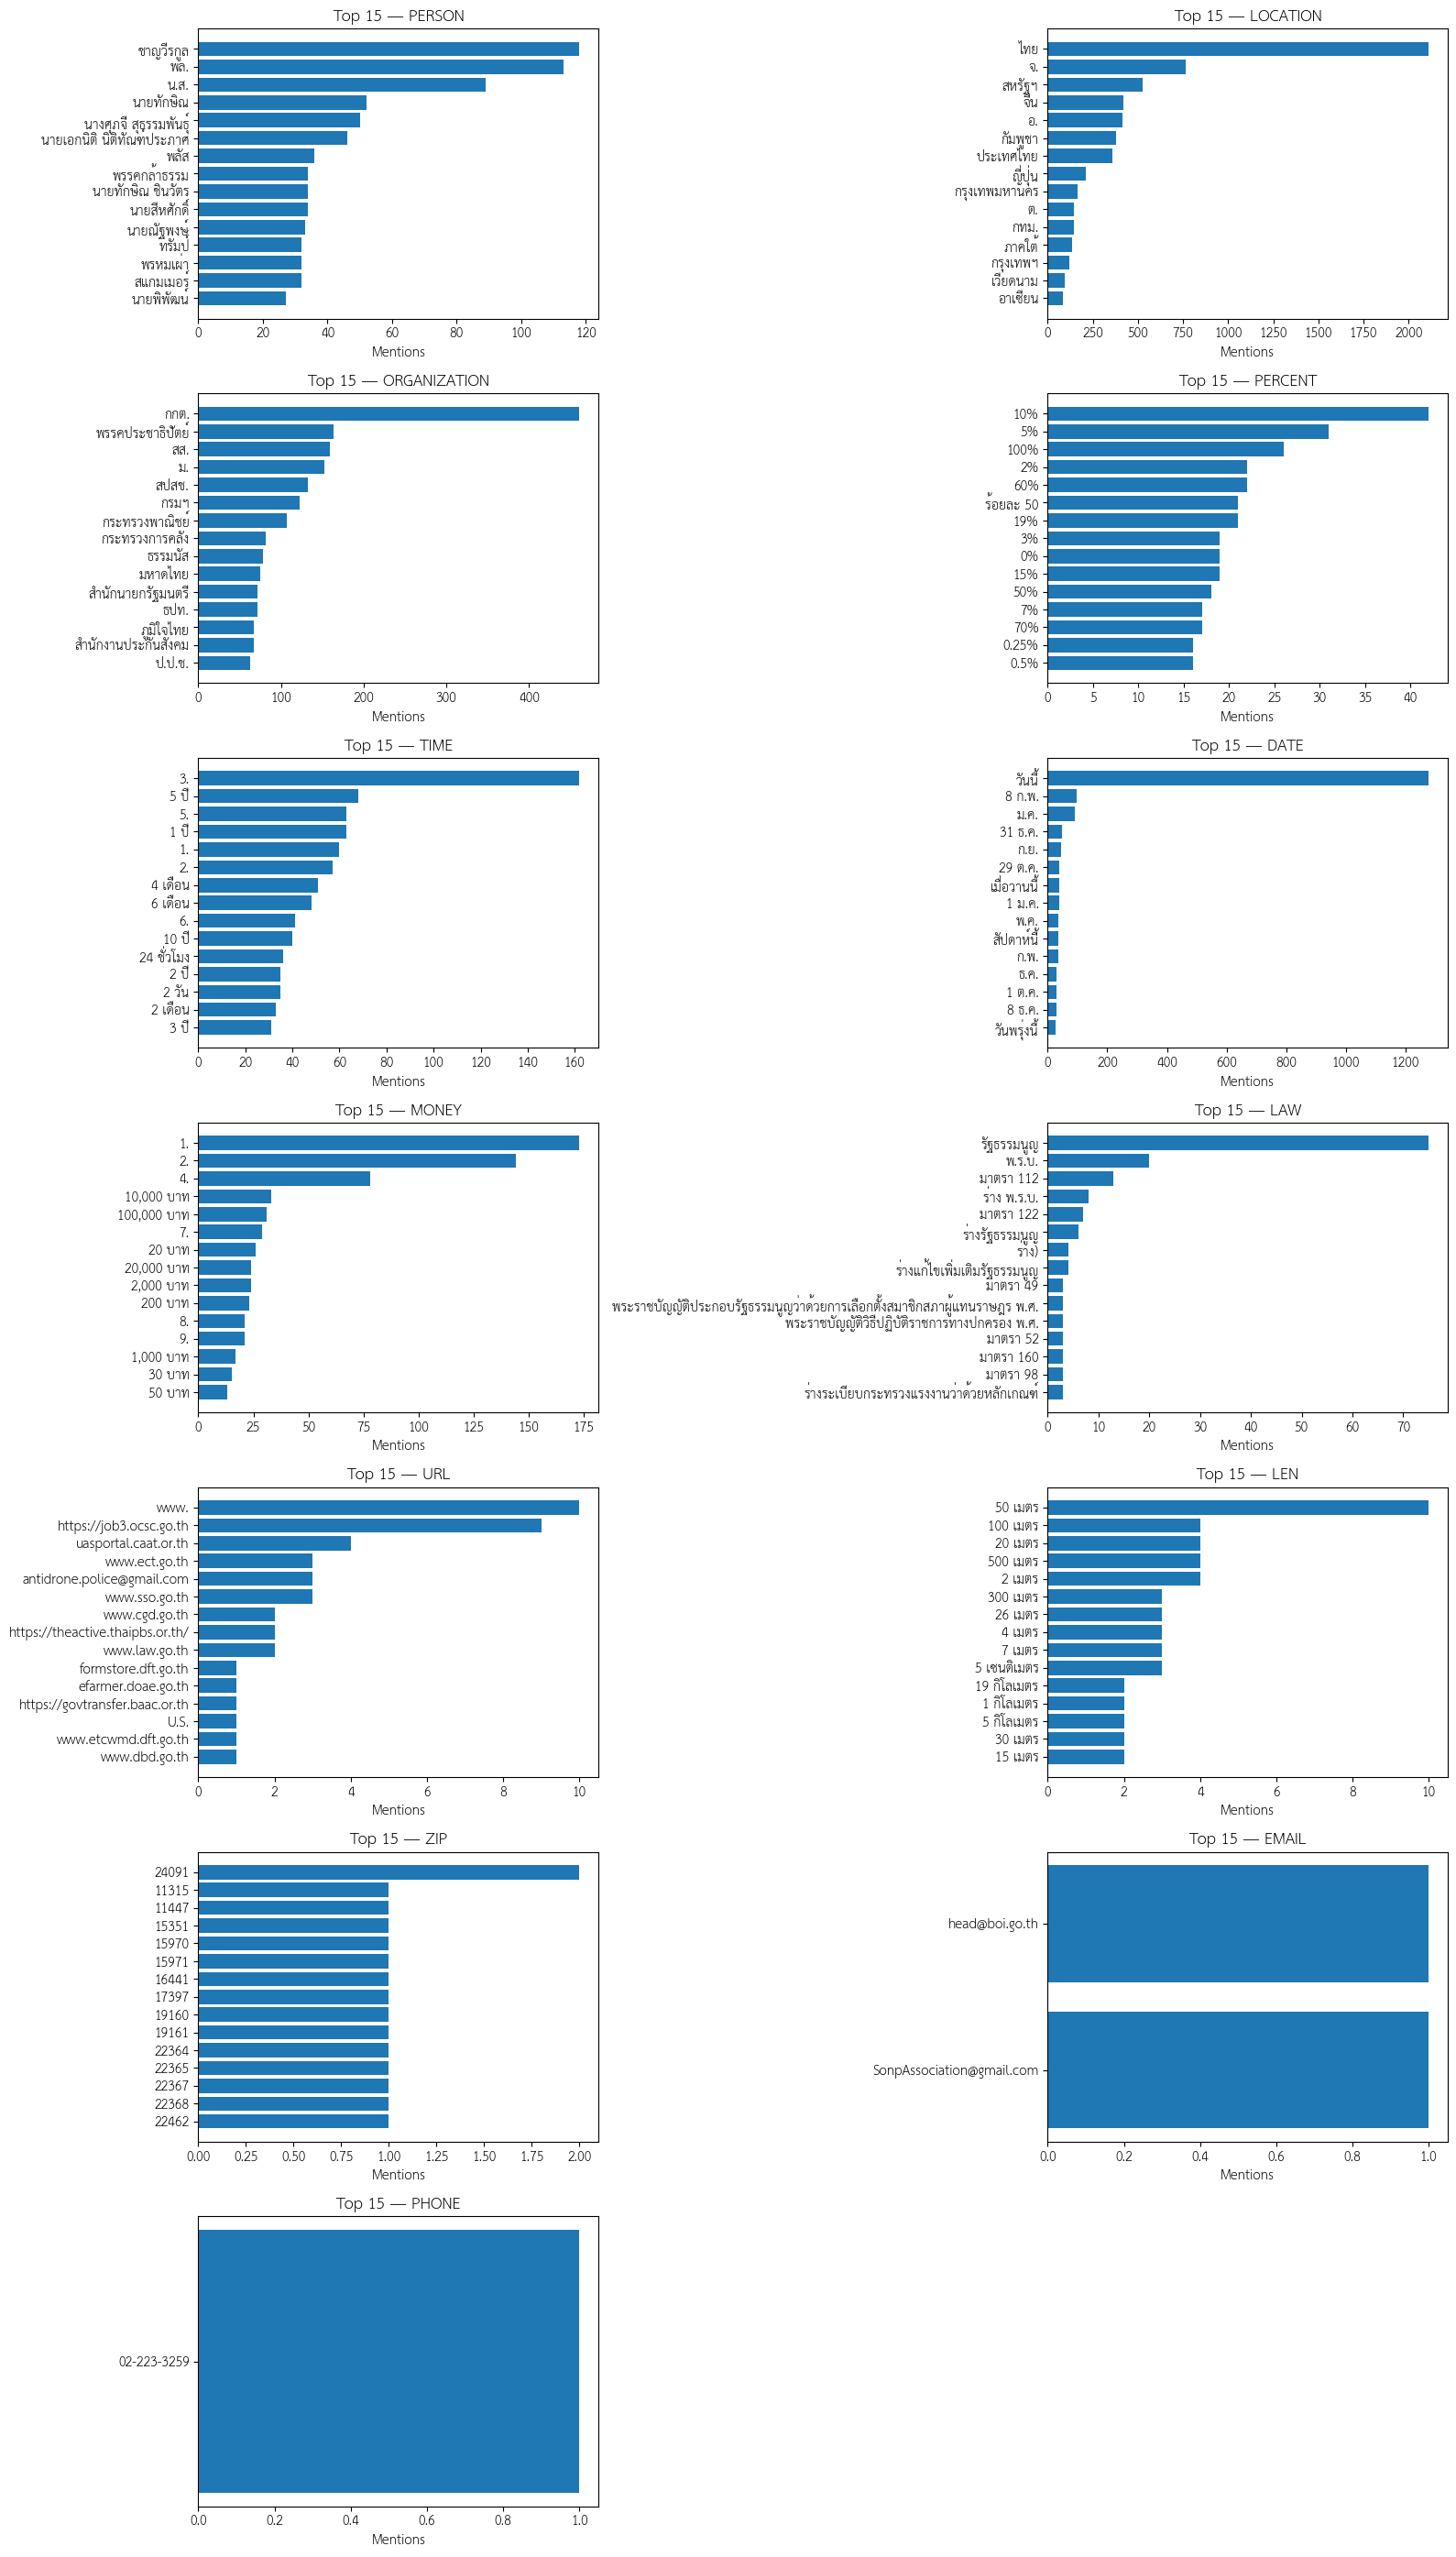

In [16]:
TOP_N = 15
entity_types = entities_df["entity_type"].unique()
ncols = 2
nrows = -(-len(entity_types) // ncols)  # ceiling division

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
axes = axes.flatten()

for ax, etype in zip(axes, entity_types):
    top = (
        entities_df[entities_df["entity_type"] == etype]["entity"]
        .value_counts()
        .head(TOP_N)
    )
    ax.barh(top.index[::-1], top.values[::-1])
    ax.set_title(f"Top {TOP_N} — {etype}")
    ax.set_xlabel("Mentions")

# Hide unused subplots
for ax in axes[len(entity_types):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

## Inspect Articles by Entity Token

In [17]:
# Set the token and optional entity type to inspect
INSPECT_TOKEN = "ม."
INSPECT_TYPE = None  # Set to e.g. "LOCATION" to filter by type, or None for any type

mask = entities_df["entity"] == INSPECT_TOKEN
if INSPECT_TYPE:
    mask &= entities_df["entity_type"] == INSPECT_TYPE

matched = entities_df[mask]
print(f"'{INSPECT_TOKEN}' appears {len(matched):,} times across {matched.index.nunique():,} mentions")
print(f"\nEntity type breakdown:")
print(matched["entity_type"].value_counts())
print(f"\nCategory breakdown:")
print(matched["category"].value_counts())

# Find source articles that contain this entity
article_indices = []
for idx, row in tpbs_df.iterrows():
    for entity_text, entity_type in extract_entities(row["ner_sentences"]):
        if entity_text == INSPECT_TOKEN and (INSPECT_TYPE is None or entity_type == INSPECT_TYPE):
            article_indices.append(idx)
            break

print(f"\nFound in {len(article_indices)} articles. Showing first 5:\n")
for idx in article_indices[:5]:
    row = tpbs_df.iloc[idx]
    print(f"[{row['categoryName']}] {row['title']}")
    sentences = row["sentences"]
    # Show sentences containing the token
    for i, sentence in enumerate(sentences):
        if INSPECT_TOKEN in sentence:
            print(f"[{i:>02}]  > {repr(sentence.strip()[:120])}")
            for j in range(i + 1, min(i + 3, len(sentences))):
                print(f"    ... {repr(sentences[j].strip()[:120])}")
            print()
    print()

'ม.' appears 154 times across 154 mentions

Entity type breakdown:
entity_type
ORGANIZATION    152
LOCATION          2
Name: count, dtype: int64

Category breakdown:
category
สังคม       144
เศรษฐกิจ      5
การเมือง      5
Name: count, dtype: int64

Found in 19 articles. Showing first 5:

[เศรษฐกิจ] หนี้ครัวเรือนไทยสูงสุดรอบ 4 ปี เฉลี่ยบ้านละ 7.4 แสนบาท
[04]  > 'ม.'
    ... 'หอการค้าไทย'
    ... 'เปิดเผยถึงผลการสำรวจสถานภาพหนี้ครัวเรือนไทยปี 2568 ว่า ครัวเรือนไทยส่วนใหญ่ 30.9% มีรายเฉลี่ย 5,0001-100,000 บาท/เดือน ส'

[22]  > 'มียอดชำระหนี้เพิ่มขึ้น ตกงาน และอื่นๆ\nด้านนายธนวรรธน์ พลวิชัย อธิการบดีและประธานที่ปรึกษาศูนย์พยากรณ์เศรษฐกิจและธุรกิจม.'
    ... 'หอการค้าไทย กล่าวว่าจากการสำรวจ'
    ... 'พบว่าปี2568'


[เศรษฐกิจ] ม.หอการค้าไทย คาดเงินสะพัด 9,677 ลบ. ลอยกระทงปี 68 ช่วงไว้อาลัย
[02]  > 'ม.'
    ... 'หอการค้าไทย กล่าวว่า บรรยากาศในลอยกระทงปีนี้ซึ่งอยู่ในช่วงสถานการณ์ไว้อาลัย โดยกิจการยังคงเชื่อว่ายังดำเนินตามประเพณีและ'
    ... 'ยังคงคึกคักแต่อยู่ตามความเหมาะสม และอาจจะมีการปรับเ